# Italian or American? Classifying Recipes from Ingredient Profiles

**Author:** Cecilia Lo Cicero (individual project)

**Task:** binary classification of recipes as Italian (`y = 2`) or American (`y = 1`) from 40 TF-IDF ingredient scores.
**Protocol:** stratified 10-fold cross-validation (seed 42) on the 3,200 labelled recipes; every chosen model is evaluated once on the same folds.

### Executive summary

All numbers below are mean 10-fold CV accuracies (± fold standard deviation) from Section 15.

- **Linear models plateau at about 78%.** Logistic regression 0.7775, Lasso 0.7803, Ridge 0.7781, Elastic Net 0.7803, PCR 0.7816, LDA 0.7703–0.7747; QDA (0.7587) and Gaussian Naive Bayes (0.7025) do worse.
- **Ingredient interactions carry most of the remaining signal.** A degree-2 polynomial basis with a Lasso penalty reaches 0.8934, and degree 3 with Ridge 0.9103; per-ingredient regression splines (no interactions) reach only 0.8269.
- **Tree ensembles and boosting are the strongest single models:** random forest 0.9156–0.9163, gradient boosting 0.9144, AdaBoost 0.9122, bagging 0.9119, XGBoost 0.9103, LightGBM 0.9097.
- **Stacking adds a small gain:** the stacked ensembles score 0.9197–0.9238. The final submitted six-learner stack (RF, GBM, XGBoost, LightGBM, two RBF SVMs, raw features passed through) scores **0.9216 ± 0.0092**, the same mean as the five-learner stack without LightGBM and passthrough (0.9216 ± 0.0095). The highest CV accuracy, 0.9238 ± 0.0095, belongs to the stack of RF + GBM + XGBoost + one scaled SVM (C = 10). These differences are well below one fold standard deviation.
- **Half of the data is duplicated.** 52.5% of training recipes share their exact feature vector with another training recipe, 53.6% of test recipes are identical to a training recipe, and 50.7% of CV validation rows have an exact copy in their training folds (Section 8.3). This is why a 1-nearest-neighbour classifier already reaches 0.8800, and it means CV accuracy partly measures recall of seen recipes.
- **What separates the cuisines (Section 14).** The Lasso keeps 25 of 40 ingredients; the largest Italian coefficients are wine, flour, yeast and parsley, the largest American ones white meat, water, garlic and paprika. Flour, oil, water and salt are among the five most-used split variables in both tree ensembles.

## 1. Setup and data loading

`RUN_FULL_SEARCH = False` skips the exhaustive grid and loop searches; the hyperparameters they selected are hard-coded right after each search. Set it to `True` to repeat them (several hours on a laptop). The diagnostic plots of the searches (`lasso_cv.png`, `ridge_cv.png`, `elasticnet_cv_heatmap.png`, `lda_shrinkage_cv.png`) are only regenerated when the flag is `True`.

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# --- Paths -------------------------------------------------------------
DATA_DIR = Path('../data/raw')
TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)
SUBMISSION_PATH = Path('../submission.txt')   # gitignored

# --- Reproducibility and run mode ---------------------------------------
SEED = 42
RUN_FULL_SEARCH = False   # True = re-run every exhaustive grid / loop search
np.random.seed(SEED)

# Colours used in the figures
BLUE, RED, GREY = '#2a78d6', '#e34948', '#b4b2a9'


def save_fig(name, fig=None):
    # Save a figure to ../figures at 150 dpi
    fig = fig if fig is not None else plt.gcf()
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches='tight')
    print(f'Saved figures/{name}')


def clean_columns(df):
    # Strip whitespace and a UTF-8 byte-order mark from column names
    df.columns = df.columns.str.strip().str.replace('﻿', '', regex=False)
    return df


train = clean_columns(pd.read_csv(TRAIN_PATH))
test = clean_columns(pd.read_csv(TEST_PATH))

X = train.drop('y', axis=1)
y = train['y']
X_test = test.copy()
assert list(X.columns) == list(X_test.columns)

print(f'Train shape: {X.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Class balance: {y.value_counts().sort_index().to_dict()}  (1=American, 2=Italian)')

Train shape: (3200, 40)
Test shape:  (1734, 40)
Class balance: {1: 1648, 2: 1552}  (1=American, 2=Italian)


## 2. Cross-validation setup

One `StratifiedKFold` object (10 folds, shuffled, seed 42) is shared by every final evaluation, so all models are scored on identical splits. `results` stores the mean and standard deviation of fold accuracy for each chosen model.

In [2]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
results = {}   # model name -> {'family', 'cv_acc', 'cv_std'}


def misclass(acc):
    # CV misclassification rate in %
    return f'{100 * (1 - acc):.2f}%'


def evaluate(name, model, family, X=X, y=y):
    # One 10-fold CV evaluation on the shared folds, recorded in `results`
    t0 = time.time()
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = {'family': family, 'cv_acc': scores.mean(), 'cv_std': scores.std()}
    print(f'{name:55s} CV acc {scores.mean():.4f} ± {scores.std():.4f}   '
          f'misclass {misclass(scores.mean())}   ({time.time() - t0:.0f}s)')
    return scores


print('CV setup ready: 10-fold StratifiedKFold, seed =', SEED)

CV setup ready: 10-fold StratifiedKFold, seed = 42


---
## 3. Linear methods

Linear classifiers assume a linear decision boundary in ingredient space. Plain logistic regression is compared with regularised variants (Lasso, Ridge, Elastic Net); the regularisation strength is tuned by 10-fold CV.

### 3.1 Logistic regression (baseline)

Standard logistic regression (scikit-learn default L2 penalty with C = 1, on standardised features).

Course leaderboard: 175 errors (see README, Evaluation note)

In [3]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
])
evaluate('Logistic regression', pipe_lr, 'Linear');

Logistic regression                                     CV acc 0.7775 ± 0.0242   misclass 22.25%   (7s)


### 3.2 Lasso logistic regression

The L1 penalty sets some coefficients exactly to zero, so it also selects variables. `C = 1/λ` is tuned over 30 log-spaced values in [10⁻³, 10²] by 10-fold CV.

Course leaderboard: 169 errors (see README, Evaluation note)

In [4]:
C_grid_lasso = np.logspace(-3, 2, 30)

if RUN_FULL_SEARCH:
    pipe_lasso = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l1', solver='liblinear',
                                   max_iter=1000, random_state=SEED))
    ])
    grid_lasso = GridSearchCV(pipe_lasso, param_grid={'clf__C': C_grid_lasso},
                              cv=cv, scoring='accuracy', n_jobs=-1,
                              return_train_score=True)
    grid_lasso.fit(X, y)
    print(f"Best C (= 1/λ): {grid_lasso.best_params_['clf__C']:.5f}")
    print(f'Best CV accuracy: {grid_lasso.best_score_:.4f}')

    cv_means = grid_lasso.cv_results_['mean_test_score']
    cv_stds = grid_lasso.cv_results_['std_test_score']
    plt.figure(figsize=(8, 4))
    plt.semilogx(C_grid_lasso, cv_means, 'b-o', markersize=4, label='CV accuracy')
    plt.fill_between(C_grid_lasso, cv_means - cv_stds, cv_means + cv_stds,
                     alpha=0.2, color='blue', label='±1 std')
    plt.axvline(grid_lasso.best_params_['clf__C'], color='red', linestyle='--',
                label=f"Best C = {grid_lasso.best_params_['clf__C']:.4f}")
    plt.xlabel('C  (= 1/λ, log scale)')
    plt.ylabel('CV accuracy')
    plt.title('Lasso logistic regression: tuning C by 10-fold CV')
    plt.legend()
    plt.tight_layout()
    save_fig('lasso_cv.png')
    plt.show()

# Selected by the grid above
best_C = C_grid_lasso[9]   # C ≈ 0.03562 (λ ≈ 28.07)

best_lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', C=best_C, solver='liblinear',
                               max_iter=1000, random_state=SEED))
])
evaluate('Lasso logistic regression', best_lasso_pipe, 'Linear')

# Which ingredients survive the Lasso?
best_lasso_pipe.fit(X, y)
coef = best_lasso_pipe.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'ingredient': X.columns, 'coefficient': coef})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)
nonzero = coef_df[coef_df['coefficient'] != 0]
zeroed = coef_df[coef_df['coefficient'] == 0]
print(f'\nIngredients kept by Lasso ({len(nonzero)}/{X.shape[1]}):')
print(nonzero.to_string(index=False))
print(f'\nIngredients zeroed out ({len(zeroed)}): {zeroed["ingredient"].tolist()}')

Lasso logistic regression                               CV acc 0.7803 ± 0.0233   misclass 21.97%   (0s)

Ingredients kept by Lasso (25/40):
ingredient  coefficient
white.meat    -0.962548
      wine     0.537906
     water    -0.481573
     flour     0.440262
     yeast     0.400759
    garlic    -0.275811
   parsley     0.267649
   paprika    -0.201979
       oil     0.196482
 mushrooms    -0.182214
    potato     0.170828
   cereals    -0.153306
    tomato     0.146481
     chili    -0.146267
      salt     0.140542
     sugar     0.128573
    ginger    -0.117841
    fruits    -0.108177
  red.meat    -0.106790
     seeds     0.088659
  turmeric    -0.084198
      milk    -0.054051
     onion    -0.044788
   vinegar    -0.036620
    pepper    -0.005967

Ingredients zeroed out (15): ['butter', 'corn', 'rice', 'cream', 'egg', 'chocolate', 'cheese', 'honey', 'mustard', 'pasta', 'bread', 'fish', 'seafood', 'veggies', 'legumes']


### 3.3 Ridge logistic regression

The L2 penalty shrinks all coefficients towards zero but never exactly to zero. `C` is tuned over 40 log-spaced values in [10⁻³, 10²].

Course leaderboard: 174 errors (see README, Evaluation note)

In [5]:
C_grid_ridge = np.logspace(-3, 2, 40)

if RUN_FULL_SEARCH:
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l2', solver='lbfgs',
                                   max_iter=1000, random_state=SEED))
    ])
    grid_ridge = GridSearchCV(pipe_ridge, param_grid={'clf__C': C_grid_ridge},
                              cv=cv, scoring='accuracy', n_jobs=-1,
                              return_train_score=True)
    grid_ridge.fit(X, y)
    best_C_found = grid_ridge.best_params_['clf__C']
    print(f'Best C (= 1/λ): {best_C_found:.5f}   CV accuracy: {grid_ridge.best_score_:.4f}')

    cv_means = grid_ridge.cv_results_['mean_test_score']
    cv_stds = grid_ridge.cv_results_['std_test_score']
    plt.figure(figsize=(8, 4))
    plt.semilogx(C_grid_ridge, cv_means, 'g-o', markersize=4, label='CV accuracy')
    plt.fill_between(C_grid_ridge, cv_means - cv_stds, cv_means + cv_stds,
                     alpha=0.2, color='green', label='±1 std')
    plt.axvline(best_C_found, color='red', linestyle='--', label=f'Best C = {best_C_found:.4f}')
    plt.xlabel('C  (= 1/λ, log scale)   →   left = more regularisation')
    plt.ylabel('10-fold CV accuracy')
    plt.title('Ridge logistic regression: tuning C')
    plt.legend()
    plt.tight_layout()
    save_fig('ridge_cv.png')
    plt.show()

# Selected by the grid above
best_C_ridge = C_grid_ridge[15]   # C ≈ 0.08377 (λ ≈ 11.94)

best_ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l2', C=best_C_ridge, solver='lbfgs',
                               max_iter=1000, random_state=SEED))
])
evaluate('Ridge logistic regression', best_ridge_pipe, 'Linear');

Ridge logistic regression                               CV acc 0.7781 ± 0.0239   misclass 22.19%   (0s)

### 3.4 Elastic Net logistic regression

Combines the L1 and L2 penalties: `penalty = λ [α·|β| + (1−α)·β²]`. Two tuning parameters, `C` (20 log-spaced values) and `l1_ratio` (nine values from 0.1 to 1.0), tuned jointly by 10-fold CV. Requires `solver='saga'`.

Course leaderboard: 174 errors (see README, Evaluation note)

In [6]:
C_grid_enet = np.logspace(-3, 2, 20)
l1_ratio_grid = [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 1.0]

if RUN_FULL_SEARCH:
    pipe_enet = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='elasticnet', solver='saga',
                                   max_iter=3000, random_state=SEED))
    ])
    grid_enet = GridSearchCV(pipe_enet,
                             param_grid={'clf__C': C_grid_enet, 'clf__l1_ratio': l1_ratio_grid},
                             cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True)
    grid_enet.fit(X, y)
    bC, bl1 = grid_enet.best_params_['clf__C'], grid_enet.best_params_['clf__l1_ratio']
    print(f'Best C: {bC:.5f}   best l1_ratio: {bl1:.2f}   CV accuracy: {grid_enet.best_score_:.4f}')

    res = pd.DataFrame(grid_enet.cv_results_)
    pivot = res.pivot_table(index='param_clf__l1_ratio', columns='param_clf__C',
                            values='mean_test_score')
    fig, ax = plt.subplots(figsize=(11, 4))
    cf = ax.contourf(np.log10(C_grid_enet), l1_ratio_grid, pivot.values, levels=20, cmap='viridis')
    plt.colorbar(cf, ax=ax, label='CV accuracy')
    ax.scatter(np.log10(bC), bl1, color='red', s=120, zorder=5,
               label=f'Best: C={bC:.4f}, l1={bl1}')
    ax.set_xlabel('log₁₀(C)  →  right = less regularisation')
    ax.set_ylabel('l1_ratio  (1 = Lasso, 0 = Ridge)')
    ax.set_title('Elastic Net: CV accuracy over the (C, l1_ratio) grid')
    ax.legend()
    plt.tight_layout()
    save_fig('elasticnet_cv_heatmap.png')
    plt.show()

# Selected by the grid above
best_C_enet = C_grid_enet[9]   # C ≈ 0.23357
best_l1_enet = 0.95

best_enet_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='elasticnet', C=best_C_enet, l1_ratio=best_l1_enet,
                               solver='saga', max_iter=3000, random_state=SEED))
])
evaluate('Elastic Net logistic regression', best_enet_pipe, 'Linear');

Elastic Net logistic regression                         CV acc 0.7803 ± 0.0226   misclass 21.97%   (1s)


#### Sanity check: L1 penalty with `saga` vs `liblinear`

Same L1 model at a fixed C = 0.1, fitted with the two solvers, to see whether the solver alone moves the CV accuracy.

In [7]:
for solver in ['liblinear', 'saga']:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l1', C=0.1, solver=solver,
                                   max_iter=5000, random_state=SEED))
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'L1 penalty | solver={solver:10s} | Acc: {scores.mean():.4f} ± {scores.std():.4f} '
          f'| CV misclass {misclass(scores.mean())}')

L1 penalty | solver=liblinear  | Acc: 0.7794 ± 0.0220 | CV misclass 22.06%


L1 penalty | solver=saga       | Acc: 0.7778 ± 0.0210 | CV misclass 22.22%


---
## 4. Discriminant analysis

These methods model the class-conditional distributions `P(x | y)` as multivariate Gaussians and classify by posterior probability. LDA assumes a shared covariance matrix (linear boundary); QDA gives each class its own covariance (quadratic boundary); Gaussian Naive Bayes forces the covariance to be diagonal (features independent within each class).

### 4.1 LDA, shrinkage LDA, QDA and Naive Bayes

Standard LDA, LDA with Ledoit–Wolf shrinkage (`shrinkage='auto'`), QDA with `reg_param` tuned over six values, and Gaussian Naive Bayes with `var_smoothing` tuned over 20 log-spaced values (both grids use 10-fold CV).

| Model | Course leaderboard errors (see README, Evaluation note) |
|-------|-----------|
| LDA (standard) | 169 |
| LDA (shrinkage=auto) | 167 |
| QDA | 181 |
| Naive Bayes | 225 |

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

# --- LDA (no tuning parameter) ---
best_lda_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearDiscriminantAnalysis(solver='svd'))
])
evaluate('LDA', best_lda_pipe, 'Discriminant analysis')

# --- LDA with Ledoit-Wolf shrinkage ---
best_lda_shrink_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
])
evaluate('LDA (Ledoit-Wolf shrinkage)', best_lda_shrink_pipe, 'Discriminant analysis')

# --- QDA: reg_param shrinks each class covariance towards the identity ---
if RUN_FULL_SEARCH:
    grid_qda = GridSearchCV(
        Pipeline([('scaler', StandardScaler()), ('clf', QuadraticDiscriminantAnalysis())]),
        param_grid={'clf__reg_param': [0.0, 0.01, 0.05, 0.1, 0.2, 0.5]},
        cv=cv, scoring='accuracy', n_jobs=-1)
    grid_qda.fit(X, y)
    print('QDA grid:', grid_qda.best_params_, f'{grid_qda.best_score_:.4f}')

best_reg_qda = 0.01   # selected by the grid above
best_qda_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', QuadraticDiscriminantAnalysis(reg_param=best_reg_qda))
])
evaluate('QDA (reg_param=0.01)', best_qda_pipe, 'Discriminant analysis')

# --- Gaussian Naive Bayes ---
vs_grid = np.logspace(-9, -1, 20)
if RUN_FULL_SEARCH:
    grid_nb = GridSearchCV(
        Pipeline([('scaler', StandardScaler()), ('clf', GaussianNB())]),
        param_grid={'clf__var_smoothing': vs_grid},
        cv=cv, scoring='accuracy', n_jobs=-1)
    grid_nb.fit(X, y)
    print('NB grid:', grid_nb.best_params_, f'{grid_nb.best_score_:.4f}')

best_vs_nb = vs_grid[17]   # ≈ 1.44e-02, selected by the grid above
best_nb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GaussianNB(var_smoothing=best_vs_nb))
])
evaluate('Gaussian Naive Bayes', best_nb_pipe, 'Discriminant analysis');

LDA                                                     CV acc 0.7703 ± 0.0197   misclass 22.97%   (0s)


LDA (Ledoit-Wolf shrinkage)                             CV acc 0.7725 ± 0.0222   misclass 22.75%   (0s)


QDA (reg_param=0.01)                                    CV acc 0.7587 ± 0.0200   misclass 24.13%   (0s)
Gaussian Naive Bayes                                    CV acc 0.7025 ± 0.0232   misclass 29.75%   (0s)


### 4.2 LDA: manual shrinkage grid

`shrinkage='auto'` uses the Ledoit–Wolf formula. Here the shrinkage α is searched directly over 50 values in [0, 1] by 10-fold CV.

Course leaderboard: 168 errors (see README, Evaluation note)

In [9]:
alpha_grid = np.linspace(0, 1, 50)

if RUN_FULL_SEARCH:
    grid_lda = GridSearchCV(
        Pipeline([('scaler', StandardScaler()),
                  ('clf', LinearDiscriminantAnalysis(solver='lsqr'))]),
        param_grid={'clf__shrinkage': alpha_grid},
        cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True)
    grid_lda.fit(X, y)
    best_alpha_found = grid_lda.best_params_['clf__shrinkage']
    print(f'Best α: {best_alpha_found:.4f}   CV accuracy: {grid_lda.best_score_:.4f}')

    cv_means = grid_lda.cv_results_['mean_test_score']
    cv_stds = grid_lda.cv_results_['std_test_score']
    plt.figure(figsize=(8, 4))
    plt.plot(alpha_grid, cv_means, 'b-o', markersize=3, label='CV accuracy')
    plt.fill_between(alpha_grid, cv_means - cv_stds, cv_means + cv_stds,
                     alpha=0.2, color='blue', label='±1 std')
    plt.axvline(best_alpha_found, color='red', linestyle='--', label=f'Best α = {best_alpha_found:.3f}')
    plt.axvline(0, color='gray', linestyle=':', label='α=0: standard LDA')
    plt.axvline(1, color='gray', linestyle=':')
    plt.xlabel('Shrinkage α  (0 = standard LDA, 1 = diagonal only)')
    plt.ylabel('10-fold CV accuracy')
    plt.title('LDA shrinkage: manual α grid search')
    plt.legend()
    plt.tight_layout()
    save_fig('lda_shrinkage_cv.png')
    plt.show()

best_alpha = alpha_grid[15]   # α ≈ 0.3061, selected by the grid above
best_lda_manual_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=best_alpha))
])
evaluate('LDA (shrinkage α=0.306)', best_lda_manual_pipe, 'Discriminant analysis');

LDA (shrinkage α=0.306)                                 CV acc 0.7747 ± 0.0230   misclass 22.53%   (0s)


---
## 5. Dimension reduction: principal components

The 40 standardised ingredients are first reduced to M principal components; a classifier is then fitted in that space. M is tuned over 1–39 by 10-fold CV, with logistic regression and with shrinkage LDA as the classifier.

| Model | Course leaderboard errors (see README, Evaluation note) |
|-------|-----------|
| PCR + logistic regression | 174 |
| PCR + LDA (shrinkage=auto) | 169 |

Saved figures/pca_variance.png


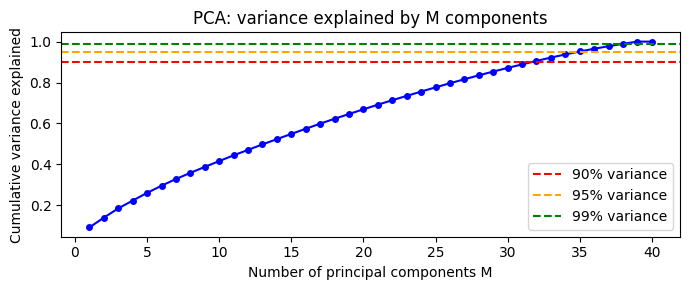

  Components needed for 90% variance: 32
  Components needed for 95% variance: 35
  Components needed for 99% variance: 39


PCR (M=31) + logistic regression                        CV acc 0.7816 ± 0.0228   misclass 21.84%   (0s)
PCR (M=34) + shrinkage LDA                              CV acc 0.7719 ± 0.0201   misclass 22.81%   (0s)


In [10]:
from sklearn.decomposition import PCA

M_grid = list(range(1, 40))

if RUN_FULL_SEARCH:
    grids_pcr = {}
    for label, clf in [('PCR + logistic regression', LogisticRegression(max_iter=1000, random_state=SEED)),
                       ('PCR + LDA (shrinkage=auto)', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))]:
        g = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('pca', PCA()), ('clf', clf)]),
                         param_grid={'pca__n_components': M_grid},
                         cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True)
        g.fit(X, y)
        grids_pcr[label] = g
        print(f"{label}: best M = {g.best_params_['pca__n_components']}, CV accuracy {g.best_score_:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (title, g), color in zip(axes, grids_pcr.items(), ['steelblue', 'darkorange']):
        means = g.cv_results_['mean_test_score']
        stds = g.cv_results_['std_test_score']
        ax.plot(M_grid, means, '-o', color=color, markersize=3, label='CV accuracy')
        ax.fill_between(M_grid, means - stds, means + stds, alpha=0.2, color=color, label='±1 std')
        ax.axvline(g.best_params_['pca__n_components'], color='red', linestyle='--',
                   label=f"Best M = {g.best_params_['pca__n_components']}")
        ax.set_xlabel('M: number of principal components kept')
        ax.set_ylabel('10-fold CV accuracy')
        ax.set_title(title)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# Variance explained (no search involved)
pca_full = PCA().fit(StandardScaler().fit_transform(X))
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(7, 3))
plt.plot(range(1, 41), cumvar, 'b-o', markersize=4)
plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
plt.axhline(0.95, color='orange', linestyle='--', label='95% variance')
plt.axhline(0.99, color='green', linestyle='--', label='99% variance')
plt.xlabel('Number of principal components M')
plt.ylabel('Cumulative variance explained')
plt.title('PCA: variance explained by M components')
plt.legend()
plt.tight_layout()
save_fig('pca_variance.png')
plt.show()
for threshold in [0.90, 0.95, 0.99]:
    print(f'  Components needed for {int(threshold * 100)}% variance: {np.argmax(cumvar >= threshold) + 1}')

# Selected by the grids above
best_M_lr, best_M_lda = 31, 34
best_pcr_lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=best_M_lr)),
    ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
])
best_pcr_lda_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=best_M_lda)),
    ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
])
evaluate('PCR (M=31) + logistic regression', best_pcr_lr_pipe, 'Dimension reduction')
evaluate('PCR (M=34) + shrinkage LDA', best_pcr_lda_pipe, 'Dimension reduction');

---
## 6. Basis functions: polynomial features

The raw ingredients are expanded into a polynomial basis: squared terms and pairwise interactions (for example `pasta × tomato`). The model stays linear in β but becomes non-linear in the original ingredients; the penalty handles the high dimensionality.

### 6.1 Polynomial features + penalised logistic regression

Three variants: (1) the full degree-2 basis (860 features) with a Lasso penalty, (2) interaction terms only (820 features) with a Lasso penalty, both with C tuned over 20 log-spaced values in [10⁻³, 10] by 10-fold CV, and (3) degree d = 1, 2, 3 with a fixed strong Ridge penalty (C = 0.01). Variant (3) is a comparison of three models, so it always runs.

| Model | Course leaderboard errors (see README, Evaluation note) |
|-------|-----------|
| Poly(d=2) + Lasso | 68 |
| Interactions only + Lasso | 76 |
| Degree 1 + Ridge | ~175 |

In [11]:
from sklearn.preprocessing import PolynomialFeatures

C_grid_poly = np.logspace(-3, 1, 20)


def poly_l1_pipe(C, interaction_only):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=interaction_only)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l1', C=C, solver='liblinear',
                                   max_iter=1000, random_state=SEED))
    ])


if RUN_FULL_SEARCH:
    for interaction_only in [False, True]:
        g = GridSearchCV(poly_l1_pipe(1.0, interaction_only), param_grid={'clf__C': C_grid_poly},
                         cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True)
        g.fit(X, y)
        print(f"interaction_only={interaction_only}: best C {g.best_params_['clf__C']:.5f}, "
              f"CV accuracy {g.best_score_:.4f}")

print('Features created (degree 2):           ',
      PolynomialFeatures(degree=2, include_bias=False).fit_transform(X).shape[1])
print('Features created (interactions only):  ',
      PolynomialFeatures(degree=2, include_bias=False, interaction_only=True).fit_transform(X).shape[1])

# Selected by the grids above
best_C_poly = C_grid_poly[13]   # C ≈ 0.54556
best_C_int = C_grid_poly[10]    # C ≈ 0.12743
evaluate('Poly(d=2) + Lasso (C=0.546)', poly_l1_pipe(best_C_poly, False), 'Basis expansion')
evaluate('Interactions only (d=2) + Lasso', poly_l1_pipe(best_C_int, True), 'Basis expansion');

Features created (degree 2):            860


Features created (interactions only):   820


Poly(d=2) + Lasso (C=0.546)                             CV acc 0.8934 ± 0.0161   misclass 10.66%   (6s)


Interactions only (d=2) + Lasso                         CV acc 0.8853 ± 0.0201   misclass 11.47%   (2s)


Poly(d=1) + Ridge (C=0.01)                              CV acc 0.7750 ± 0.0252   misclass 22.50%   (0s)


Poly(d=2) + Ridge (C=0.01)                              CV acc 0.8812 ± 0.0135   misclass 11.88%   (1s)


Poly(d=3) + Ridge (C=0.01)                              CV acc 0.9103 ± 0.0114   misclass 8.97%   (19s)


Saved figures/polynomial_cv_degree.png


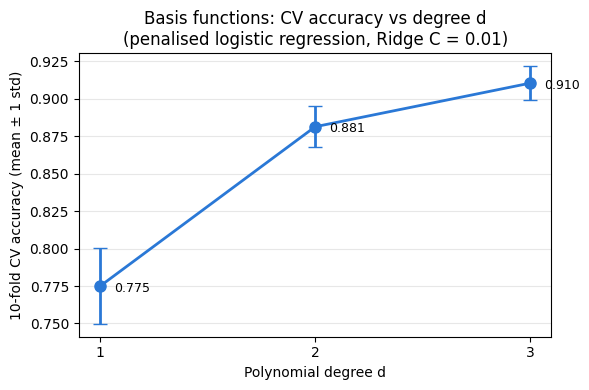

In [12]:
# Degree d = 1, 2, 3 with a fixed strong Ridge penalty
degree_grid = [1, 2, 3]
degree_scores = {}
for d in degree_grid:
    pipe_d = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l2', C=0.01, solver='lbfgs',
                                   max_iter=2000, random_state=SEED))
    ])
    degree_scores[d] = evaluate(f'Poly(d={d}) + Ridge (C=0.01)', pipe_d, 'Basis expansion')

means = [degree_scores[d].mean() for d in degree_grid]
stds = [degree_scores[d].std() for d in degree_grid]
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(degree_grid, means, yerr=stds, fmt='-o', color=BLUE, capsize=5,
            linewidth=2, markersize=8)
for d, m in zip(degree_grid, means):
    ax.annotate(f'{m:.3f}', (d, m), textcoords='offset points', xytext=(10, -4), fontsize=9)
ax.set_xlabel('Polynomial degree d')
ax.set_ylabel('10-fold CV accuracy (mean ± 1 std)')
ax.set_title('Basis functions: CV accuracy vs degree d\n(penalised logistic regression, Ridge C = 0.01)')
ax.set_xticks(degree_grid)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig('polynomial_cv_degree.png')
plt.show()

### 6.2 Lasso vs Ridge vs Elastic Net on the degree-2 basis

The degree-2 basis is computed and standardised once for the searches (C over 15 log-spaced values in [10⁻⁴, 10], 10-fold CV; the Elastic Net search uses `LogisticRegressionCV` with `l1_ratio` ∈ {0.8, 0.9, 0.95, 1.0}). The chosen models are then evaluated as full pipelines, so the basis and the scaler are fitted inside each fold.

| Model | Course leaderboard errors (see README, Evaluation note) |
|-------|-----------|
| Poly + Lasso | 68 |
| Poly + Ridge | 70 |
| Poly + Elastic Net | 73 |

In [13]:
from sklearn.linear_model import LogisticRegressionCV

DEGREE, INTERACT = 2, False
C_grid_poly2 = np.logspace(-4, 1, 15)

if RUN_FULL_SEARCH:
    poly = PolynomialFeatures(degree=DEGREE, interaction_only=INTERACT, include_bias=False)
    X_poly = StandardScaler().fit_transform(poly.fit_transform(X))   # (3200, 860)
    for name, est in [('Lasso', LogisticRegression(penalty='l1', solver='liblinear',
                                                   max_iter=2000, random_state=SEED)),
                      ('Ridge', LogisticRegression(penalty='l2', solver='lbfgs',
                                                   max_iter=2000, random_state=SEED))]:
        g = GridSearchCV(est, {'C': C_grid_poly2}, cv=cv, scoring='accuracy', n_jobs=-1)
        g.fit(X_poly, y)
        print(f"Poly + {name}: best C {g.best_params_['C']:.5f}, CV accuracy {g.best_score_:.4f}")
    enet_cv = LogisticRegressionCV(Cs=C_grid_poly2, l1_ratios=[0.8, 0.9, 0.95, 1.0],
                                   penalty='elasticnet', solver='saga', cv=cv,
                                   scoring='accuracy', max_iter=1000, tol=1e-3,
                                   n_jobs=-1, random_state=SEED)
    enet_cv.fit(X_poly, y)
    print(f'Poly + Elastic Net: best C {enet_cv.C_[0]:.5f}, l1_ratio {enet_cv.l1_ratio_[0]}')

# Selected by the searches above
best_C_lasso = C_grid_poly2[11]   # C ≈ 0.84834
best_C_ridge2 = C_grid_poly2[10]  # C ≈ 0.37276
best_C_enet2, best_l1_enet2 = 10.0, 0.9


def poly2(clf):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=DEGREE, interaction_only=INTERACT, include_bias=False)),
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])


best_poly_lasso_pipe = poly2(LogisticRegression(penalty='l1', C=best_C_lasso, solver='liblinear',
                                                max_iter=2000, random_state=SEED))
best_poly_ridge_pipe = poly2(LogisticRegression(penalty='l2', C=best_C_ridge2, solver='lbfgs',
                                                max_iter=2000, random_state=SEED))
best_poly_enet_pipe = poly2(LogisticRegression(penalty='elasticnet', C=best_C_enet2,
                                               l1_ratio=best_l1_enet2, solver='saga',
                                               max_iter=3000, random_state=SEED))
evaluate('Poly(d=2) + Lasso (C=0.848)', best_poly_lasso_pipe, 'Basis expansion')
evaluate('Poly(d=2) + Ridge (C=0.373)', best_poly_ridge_pipe, 'Basis expansion')
evaluate('Poly(d=2) + Elastic Net (C=10, l1=0.9)', best_poly_enet_pipe, 'Basis expansion');

Poly(d=2) + Lasso (C=0.848)                             CV acc 0.8903 ± 0.0151   misclass 10.97%   (8s)


Poly(d=2) + Ridge (C=0.373)                             CV acc 0.8912 ± 0.0176   misclass 10.88%   (2s)


Poly(d=2) + Elastic Net (C=10, l1=0.9)                  CV acc 0.8887 ± 0.0184   misclass 11.13%   (342s)


### 6.3 Joint tuning: degree × interaction × C

A joint grid over degree ∈ {2, 3}, `interaction_only` ∈ {True, False} and 23 values of C (10-fold CV) was started but not completed in the original analysis (degree 3 creates 12,340 features). The C value was then fine-tuned on the degree-2 basis only: 15 values in [0.05, 2.0], then 10 values in ±30% of the best (10-fold CV on the pre-standardised basis).

Course leaderboard: 72 errors (see README, Evaluation note)

In [14]:
if RUN_FULL_SEARCH:
    C_grid_joint = np.unique(np.round(np.concatenate([
        np.logspace(-3, -1, 8), np.logspace(-1, 0.5, 12), np.logspace(0.5, 1.5, 5)]), 6))
    pipe_joint = Pipeline([
        ('poly', PolynomialFeatures(include_bias=False)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, random_state=SEED))
    ])
    grid_joint = GridSearchCV(pipe_joint,
                              {'poly__degree': [2, 3], 'poly__interaction_only': [False, True],
                               'clf__C': C_grid_joint},
                              cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_joint.fit(X, y)
    print('Joint grid:', grid_joint.best_params_, f'{grid_joint.best_score_:.4f}')

    # Fine search of C on the standardised degree-2 basis
    Xp_best = StandardScaler().fit_transform(PolynomialFeatures(degree=2, include_bias=False).fit_transform(X))

    def quick_cv_poly(C):
        clf = LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=2000, random_state=SEED)
        s = cross_val_score(clf, Xp_best, y, cv=cv, scoring='accuracy', n_jobs=-1)
        return s.mean()

    best_C_final, best_score_final = None, 0
    for C in np.linspace(0.05, 2.0, 15):
        m = quick_cv_poly(C)
        print(f'  C={C:.4f} → CV misclass {misclass(m)}')
        if m > best_score_final:
            best_score_final, best_C_final = m, C
    for C in np.linspace(best_C_final * 0.7, best_C_final * 1.3, 10):
        m = quick_cv_poly(C)
        print(f'  C={C:.5f} → CV misclass {misclass(m)}')
        if m > best_score_final:
            best_score_final, best_C_final = m, C
    print(f'Best C: {best_C_final:.6f}')

# Selected by the fine search above: np.linspace(0.7*c, 1.3*c, 10)[3] with c = np.linspace(0.05, 2.0, 15)[4]
best_C_joint = 0.5464285714285715
best_poly_joint_pipe = poly2(LogisticRegression(penalty='l1', C=best_C_joint, solver='liblinear',
                                                max_iter=2000, random_state=SEED))
evaluate('Poly(d=2) + Lasso (fine-tuned C=0.546)', best_poly_joint_pipe, 'Basis expansion');

Poly(d=2) + Lasso (fine-tuned C=0.546)                  CV acc 0.8937 ± 0.0157   misclass 10.63%   (3s)


---
## 7. Splines

Regression splines apply a piecewise-cubic basis to each ingredient separately, joined smoothly at K knots placed at quantiles. They are more flexible per ingredient than polynomials but, as used here, contain no interactions between ingredients.

### 7.1 Regression splines + Lasso

Coarse-to-fine search over the number of knots K and the Lasso C (10-fold CV): a coarse 5 × 5 grid, a finer grid around the best K and C, then an ultra-fine C grid. The search was interrupted during the fine stage in the original run; the configuration below (K = 10, C = 8.14913) is the one that was hard-coded afterwards.

Course leaderboard: 122 errors (see README, Evaluation note)

In [15]:
from sklearn.preprocessing import SplineTransformer


def spline_pipe(n_knots, C, max_iter=1000):
    return Pipeline([
        ('spline', SplineTransformer(n_knots=n_knots, degree=3, extrapolation='linear',
                                     include_bias=False)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l1', C=C, solver='liblinear',
                                   max_iter=max_iter, random_state=SEED))
    ])


def quick_cv_spline(n_knots, C):
    s = cross_val_score(spline_pipe(n_knots, C), X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    return s.mean(), s.std()


if RUN_FULL_SEARCH:
    best_coarse, best_K_c, best_C_c = 0, 3, 0.1
    for K in [2, 3, 5, 7, 10]:
        for C in np.logspace(-3, 1, 5):
            m, _ = quick_cv_spline(K, C)
            print(f'  K={K:2d} C={C:.4f} → CV misclass {misclass(m)}')
            if m > best_coarse:
                best_coarse, best_K_c, best_C_c = m, K, C
    best_fine, best_K_f, best_C_f = 0, best_K_c, best_C_c
    for K in sorted({max(2, best_K_c - 1), best_K_c, best_K_c + 1, best_K_c + 2}):
        for C in np.logspace(np.log10(best_C_c) - 0.8, np.log10(best_C_c) + 0.8, 10):
            m, _ = quick_cv_spline(K, C)
            print(f'  K={K:2d} C={C:.5f} → CV misclass {misclass(m)}')
            if m > best_fine:
                best_fine, best_K_f, best_C_f = m, K, C
    for C in np.linspace(best_C_f * 0.6, best_C_f * 1.4, 10):
        m, _ = quick_cv_spline(best_K_f, C)
        print(f'  K={best_K_f} C={C:.6f} → CV misclass {misclass(m)}')

best_spline_pipe = spline_pipe(n_knots=10, C=8.14913, max_iter=2000)
print('Features created:', best_spline_pipe.named_steps['spline'].fit_transform(X).shape[1])
evaluate('Regression splines (K=10) + Lasso', best_spline_pipe, 'Basis expansion');

Features created: 440


Regression splines (K=10) + Lasso                       CV acc 0.8269 ± 0.0219   misclass 17.31%   (19s)


### 7.2 Lasso-selected degree-2 terms + raw features

The degree-2 terms kept by `best_poly_lasso_pipe` (non-zero coefficients after fitting on all 3,200 recipes) are stacked with the 40 raw ingredients, standardised once, and fed to Lasso, Ridge and Elastic Net logistic regression (15 log-spaced C values in [10⁻³, 10]; l1_ratio ∈ {0.7, 0.8, 0.9, 0.95, 1.0}; 10-fold CV). Although the original notebook labelled this "splines on interactions", no spline basis is involved in this matrix.

**Caveat:** the term selection used all training labels before cross-validation, so the CV accuracy of this model is optimistically biased.

Course leaderboard: 75 errors for the Ridge model (see README, Evaluation note)

In [16]:
# Step 1: degree-2 terms selected by the Lasso
best_poly_lasso_pipe.fit(X, y)
poly_step = best_poly_lasso_pipe.named_steps['poly']
nonzero_mask = best_poly_lasso_pipe.named_steps['clf'].coef_[0] != 0
X_sel = poly_step.transform(X)[:, nonzero_mask]
print(f'Degree-2 terms: {nonzero_mask.size}, kept by Lasso: {nonzero_mask.sum()}')

# Step 2: stack with the raw ingredients and standardise
X_sel_enriched = np.hstack([X_sel, X.values])
X_sel_enriched_sc = StandardScaler().fit_transform(X_sel_enriched)
print(f'Enriched matrix: {X_sel_enriched_sc.shape[1]} columns')

C_grid_sel = np.logspace(-3, 1, 15)
if RUN_FULL_SEARCH:
    def quick_cv_sel(clf):
        s = cross_val_score(clf, X_sel_enriched_sc, y, cv=cv, scoring='accuracy', n_jobs=-1)
        return s.mean()
    for C in C_grid_sel:
        print(f"  Lasso C={C:.5f} → {misclass(quick_cv_sel(LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=1000, random_state=SEED)))}")
    for C in C_grid_sel:
        print(f"  Ridge C={C:.5f} → {misclass(quick_cv_sel(LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=1000, random_state=SEED)))}")
    for l1 in [0.7, 0.8, 0.9, 0.95, 1.0]:
        for C in C_grid_sel:
            print(f"  Enet l1={l1} C={C:.5f} → {misclass(quick_cv_sel(LogisticRegression(penalty='elasticnet', C=C, l1_ratio=l1, solver='saga', max_iter=1000, random_state=SEED)))}")

# Selected by the search above: Ridge, C ≈ 0.19307
best_enrich_ridge_clf = LogisticRegression(penalty='l2', C=C_grid_sel[8], solver='lbfgs',
                                           max_iter=2000, random_state=SEED)
evaluate('Lasso-selected d=2 terms + raw, Ridge', best_enrich_ridge_clf, 'Basis expansion',
         X=X_sel_enriched_sc);

Degree-2 terms: 860, kept by Lasso: 523
Enriched matrix: 563 columns


Lasso-selected d=2 terms + raw, Ridge                   CV acc 0.9075 ± 0.0124   misclass 9.25%   (1s)


### 7.3 Regression splines: quick 5-fold grid

A second, smaller spline search with quantile knots and default (constant) extrapolation: **5-fold CV** over n_knots ∈ {3, 5, 10} and C ∈ {0.01, 0.1, 1.0}. The chosen configuration is then evaluated with the common 10-fold CV.

Course leaderboard: 147 errors (see README, Evaluation note)

In [17]:
if RUN_FULL_SEARCH:
    grid_spline = GridSearchCV(
        Pipeline([
            ('spline', SplineTransformer(degree=3, knots='quantile', include_bias=False)),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, random_state=SEED))
        ]),
        {'spline__n_knots': [3, 5, 10], 'clf__C': [0.01, 0.1, 1.0]},
        cv=5, scoring='accuracy', n_jobs=-1)
    grid_spline.fit(X, y)
    print('Spline grid:', grid_spline.best_params_, f'{grid_spline.best_score_:.4f}')

# Selected by the grid above
best_spline_quick_pipe = Pipeline([
    ('spline', SplineTransformer(n_knots=5, degree=3, knots='quantile', include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=2000, random_state=SEED))
])
evaluate('Regression splines (K=5, quick grid) + Lasso', best_spline_quick_pipe, 'Basis expansion');

Regression splines (K=5, quick grid) + Lasso            CV acc 0.8094 ± 0.0205   misclass 19.06%   (1s)


---
## 8. Local methods: k-nearest neighbours

KNN predicts from the K closest training recipes in standardised ingredient space; small K is flexible, large K is smooth.

### 8.1 KNN on the raw features

Coarse-to-fine search with **5-fold CV**: K ∈ {5, 15, 51, 101, 201}, then K ∈ {1, 2, 3, 4, 5, 7, 10}, then the distance metric (Euclidean, cosine, Manhattan) at K = 1.

Course leaderboard: 80 errors (K = 1, Euclidean) (see README, Evaluation note)

In [18]:
from sklearn.neighbors import KNeighborsClassifier


def knn_pipe(k, metric='minkowski'):
    return Pipeline([('scaler', StandardScaler()),
                     ('clf', KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=-1))])


if RUN_FULL_SEARCH:
    for k in [5, 15, 51, 101, 201] + [1, 2, 3, 4, 7, 10]:
        s = cross_val_score(knn_pipe(k), X, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'K={k:4d}  Acc: {s.mean():.4f}  CV misclass {misclass(s.mean())}')
    for metric in ['euclidean', 'cosine', 'manhattan']:
        s = cross_val_score(knn_pipe(1, metric), X, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'{metric:12s}  Acc: {s.mean():.4f}  CV misclass {misclass(s.mean())}')

best_knn_pipe = knn_pipe(1, 'euclidean')   # selected by the searches above
evaluate('1-nearest neighbour (Euclidean)', best_knn_pipe, 'Local methods');

1-nearest neighbour (Euclidean)                         CV acc 0.8800 ± 0.0175   misclass 12.00%   (1s)


### 8.2 KNN on the interaction-enriched matrix

The 820 pairwise interaction terms (zero-variance columns dropped) are stacked with the 40 raw ingredients and standardised once. The same matrix is reused by the decision tree in Section 10.1. K ∈ {1, 2, 3} was compared with **5-fold CV**.

Course leaderboard: 86 errors (see README, Evaluation note)

In [19]:
poly_int = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_int = poly_int.fit_transform(X)
var_mask = X_int.var(axis=0) > 0
X_enriched = np.hstack([X_int[:, var_mask], X.values])
X_enriched_sc = StandardScaler().fit_transform(X_enriched)
print(f'Enriched features: {X_enriched_sc.shape[1]}')

if RUN_FULL_SEARCH:
    for k in [1, 2, 3]:
        s = cross_val_score(KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1),
                            X_enriched_sc, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'K={k}  Acc: {s.mean():.4f}  CV misclass {misclass(s.mean())}')

evaluate('1-NN on interaction-enriched features',
         KNeighborsClassifier(n_neighbors=1, metric='euclidean', n_jobs=-1),
         'Local methods', X=X_enriched_sc);

Enriched features: 838


1-NN on interaction-enriched features                   CV acc 0.8753 ± 0.0165   misclass 12.47%   (0s)


### 8.3 Diagnostic: exact duplicate recipes

A 1-nearest-neighbour classifier scores well above every linear model. One possible explanation is that identical feature vectors occur more than once. This cell counts exact duplicate rows within the training set and between training and test sets; it does not change any model.

In [20]:
key_train = pd.util.hash_pandas_object(X, index=False)
key_test = pd.util.hash_pandas_object(X_test, index=False)

dup_mask = key_train.duplicated(keep=False)
print(f'Training rows whose feature vector appears more than once: {dup_mask.sum()} of {len(X)} '
      f'({100 * dup_mask.mean():.1f}%)')
print(f'Distinct feature vectors among them:                       {key_train[dup_mask].nunique()}')
print(f'Redundant training rows (beyond the first copy):           {key_train.duplicated().sum()}')

groups = pd.DataFrame({'key': key_train, 'y': y.values})[dup_mask].groupby('key')['y'].nunique()
print(f'Duplicate groups with conflicting labels:                  {(groups > 1).sum()} of {len(groups)}')

in_train = key_test.isin(set(key_train))
print(f'Test rows identical to at least one training row:          {in_train.sum()} of {len(X_test)} '
      f'({100 * in_train.mean():.1f}%)')
print(f'All-zero rows: train {int((X.sum(axis=1) == 0).sum())}, test {int((X_test.sum(axis=1) == 0).sum())}')

# Share of CV test-fold rows that have an exact copy in the corresponding training folds
hits = 0
for tr, te in cv.split(X, y):
    hits += key_train.iloc[te].isin(set(key_train.iloc[tr])).sum()
print(f'CV validation rows with an exact copy in their training folds: {hits} of {len(X)} '
      f'({100 * hits / len(X):.1f}%)')

Training rows whose feature vector appears more than once: 1679 of 3200 (52.5%)
Distinct feature vectors among them:                       402
Redundant training rows (beyond the first copy):           1277
Duplicate groups with conflicting labels:                  23 of 402
Test rows identical to at least one training row:          930 of 1734 (53.6%)
All-zero rows: train 0, test 0
CV validation rows with an exact copy in their training folds: 1623 of 3200 (50.7%)


---
## 9. MARS-style model: hinge basis functions

MARS builds an adaptive piecewise-linear basis from hinge functions `(x − t)+` and `(t − x)+`. Here it is approximated by hand: one hinge pair at the median of each ingredient, optionally the pairwise products of the positive hinges (degree 2), and a Lasso penalty to select the active terms. (`sklearn-contrib-py-earth` did not install in the original environment.) The hinge matrix is standardised once on the full training set.

### 9.1 Hinge features + Lasso

Degree 1 vs degree 2 with two C values, then three successively finer C grids for degree 2, all with **5-fold CV**.

Course leaderboard: ~67 errors (degree 2, C ≈ 0.42) (see README, Evaluation note)

In [21]:
def make_hinge_features(Xdf, degree=1):
    X_arr = Xdf.values
    n, p = X_arr.shape
    thresholds = np.median(X_arr, axis=0)          # hinge at the median of each feature
    pos = np.maximum(X_arr - thresholds, 0)
    neg = np.maximum(thresholds - X_arr, 0)
    H = np.hstack([pos, neg])                       # (n, 2p)
    if degree == 2:                                 # products of positive hinges
        pairs = [pos[:, i] * pos[:, j] for i in range(p) for j in range(i + 1, p)]
        H = np.hstack([H, np.column_stack(pairs)])
    return H


def hinge_lasso(C):
    return LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=2000, random_state=SEED)


if RUN_FULL_SEARCH:
    for degree in [1, 2]:
        H_tmp = StandardScaler().fit_transform(make_hinge_features(X, degree=degree))
        for C in [0.01, 0.1]:
            s = cross_val_score(hinge_lasso(C), H_tmp, y, cv=5, scoring='accuracy', n_jobs=-1)
            print(f'degree={degree}  C={C}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')

H = make_hinge_features(X, degree=2)
H_sc = StandardScaler().fit_transform(H)
print(f'Hinge features (degree 2): {H.shape[1]}')

if RUN_FULL_SEARCH:
    for C in [0.1, 0.5, 1.0, 5.0, 10.0] + [0.3, 0.4, 0.6, 0.7] + [0.35, 0.38, 0.42, 0.45]:
        s = cross_val_score(hinge_lasso(C), H_sc, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'C={C:<5}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')

evaluate('MARS-style hinges (d=2) + Lasso', hinge_lasso(0.42), 'Basis expansion', X=H_sc);

Hinge features (degree 2): 860


MARS-style hinges (d=2) + Lasso                         CV acc 0.8950 ± 0.0155   misclass 10.50%   (2s)


### 9.2 Hinge features + raw ingredients

The hinge basis stacked with the 40 raw ingredients (standardised once); C ∈ {0.3, 0.42, 0.5} compared with **5-fold CV**.

In [22]:
H_enrich_sc = StandardScaler().fit_transform(np.hstack([H, X.values]))

if RUN_FULL_SEARCH:
    for C in [0.3, 0.42, 0.5]:
        s = cross_val_score(hinge_lasso(C), H_enrich_sc, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'C={C}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')

evaluate('MARS-style hinges + raw features + Lasso', hinge_lasso(0.42), 'Basis expansion',
         X=H_enrich_sc);

MARS-style hinges + raw features + Lasso                CV acc 0.8950 ± 0.0155   misclass 10.50%   (2s)


---
## 10. Tree-based methods

Decision trees partition ingredient space with recursive binary splits. A single tree has high variance; bagging and random forests average many trees to reduce it.

### 10.1 Single decision tree

`max_depth` (coarse, then fine) and the cost-complexity parameter `ccp_alpha` (coarse, then fine) are searched with **5-fold CV** on the raw features; `ccp_alpha` is also searched on the interaction-enriched matrix of Section 8.2. For the raw features the best 5-fold value, `ccp_alpha = 0.0005`, is used.

| Variant | Course leaderboard errors (see README, Evaluation note) |
|---------|-----------|
| Single tree (raw features) | 83 |
| Single tree (enriched features, α = 0) | 72 |

In [23]:
from sklearn.tree import DecisionTreeClassifier

if RUN_FULL_SEARCH:
    for depth in [2, 3, 5, 10, 20, None] + [15, 18, 25, 30]:
        s = cross_val_score(DecisionTreeClassifier(max_depth=depth, random_state=SEED),
                            X, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'depth={str(depth):5s}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')
    for alpha in [0.0, 0.0001, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.001, 0.005, 0.01]:
        s = cross_val_score(DecisionTreeClassifier(ccp_alpha=alpha, random_state=SEED),
                            X, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'alpha={alpha}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')
    for alpha in [0.0, 0.00005, 0.0001, 0.0002, 0.0005]:
        s = cross_val_score(DecisionTreeClassifier(ccp_alpha=alpha, random_state=SEED),
                            X_enriched_sc, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'enriched alpha={alpha}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')

evaluate('Decision tree (ccp_alpha=0.0005)',
         DecisionTreeClassifier(ccp_alpha=0.0005, random_state=SEED), 'Trees')
evaluate('Decision tree on enriched features (alpha=0)',
         DecisionTreeClassifier(ccp_alpha=0.0, random_state=SEED), 'Trees', X=X_enriched_sc);

Decision tree (ccp_alpha=0.0005)                        CV acc 0.8887 ± 0.0196   misclass 11.13%   (0s)


Decision tree on enriched features (alpha=0)            CV acc 0.8841 ± 0.0193   misclass 11.59%   (1s)


### 10.2 Bagging

Bootstrap aggregation of full-depth trees. Number of trees, tree depth, `max_samples` and `max_features` are searched with **5-fold CV**.

Course leaderboard: 58 errors (B = 80, max_features = 0.7) (see README, Evaluation note)

In [24]:
from sklearn.ensemble import BaggingClassifier

if RUN_FULL_SEARCH:
    for n in [10, 30, 40, 50, 60, 70, 75, 100, 150, 200]:
        s = cross_val_score(BaggingClassifier(n_estimators=n, random_state=SEED, n_jobs=-1),
                            X, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'n_estimators={n:4d}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')
    for depth in [10, 15, 20, None]:
        s = cross_val_score(BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=depth, random_state=SEED),
                                              n_estimators=50, random_state=SEED, n_jobs=-1),
                            X, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'depth={str(depth):5s}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')
    for max_samp in [0.7, 0.8, 1.0]:
        for max_feat in [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 1.0]:
            s = cross_val_score(BaggingClassifier(n_estimators=50, max_samples=max_samp, max_features=max_feat,
                                                  random_state=SEED, n_jobs=-1),
                                X, y, cv=5, scoring='accuracy', n_jobs=-1)
            print(f'max_samples={max_samp} max_features={max_feat}  Acc:{s.mean():.4f}')
    for n in [50, 80, 90, 100, 110, 120, 150, 200]:
        s = cross_val_score(BaggingClassifier(n_estimators=n, max_samples=1.0, max_features=0.7,
                                              random_state=SEED, n_jobs=-1),
                            X, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'n={n}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')

# Selected by the searches above
best_bagging_clf = BaggingClassifier(n_estimators=80, max_samples=1.0, max_features=0.7,
                                     random_state=SEED, n_jobs=-1)
evaluate('Bagging (B=80, max_features=0.7)', best_bagging_clf, 'Trees');

Bagging (B=80, max_features=0.7)                        CV acc 0.9119 ± 0.0122   misclass 8.81%   (2s)


### 10.3 Bagging: out-of-bag accuracy and variable importance

The same bagging configuration refitted on all training recipes with `oob_score=True` (the bootstrap samples are unchanged, since the seed is the same). Each tree only sees 70% of the ingredients, so its impurity importances are mapped back to the ingredients it used and averaged over the 80 trees.

In [25]:
best_bagging_oob = BaggingClassifier(n_estimators=80, max_samples=1.0, max_features=0.7,
                                     oob_score=True, random_state=SEED, n_jobs=-1)
best_bagging_oob.fit(X, y)
print(f'Out-of-bag accuracy: {best_bagging_oob.oob_score_:.4f}')

bag_importances = np.zeros(X.shape[1])
for tree, features in zip(best_bagging_oob.estimators_, best_bagging_oob.estimators_features_):
    bag_importances[features] += tree.feature_importances_
bag_importances /= len(best_bagging_oob.estimators_)
bag_importances = pd.Series(bag_importances, index=X.columns).sort_values(ascending=False)
print('\nTop 10 ingredients by bagging importance (mean impurity decrease):')
print(bag_importances.head(10).round(4).to_string())

Out-of-bag accuracy: 0.9106

Top 10 ingredients by bagging importance (mean impurity decrease):
flour         0.0888
oil           0.0709
water         0.0643
sugar         0.0564
salt          0.0499
white.meat    0.0453
wine          0.0408
garlic        0.0380
egg           0.0355
seeds         0.0332


### 10.4 Random forest

Like bagging, but each split considers only a random subset of m ingredients, which de-correlates the trees. m and the number of trees B are searched with 10-fold CV; `min_samples_leaf`, `min_samples_split` and the split criterion with **5-fold CV**. The configuration used later in the ensembles is m = 4, B = 200.

| Variant | Course leaderboard errors (see README, Evaluation note) |
|---------|-----------|
| RF (m = √p, B = 100) | ~60 |
| RF (m = 8, B = 200) | 56 |
| RF (m = 4, B = 200) | 52 |

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_default = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=SEED, n_jobs=-1)
evaluate('Random forest (m=sqrt(p), B=100)', rf_default, 'Trees')

if RUN_FULL_SEARCH:
    for m in ['sqrt', 20, 40]:
        s = cross_val_score(RandomForestClassifier(n_estimators=100, max_features=m, random_state=SEED, n_jobs=-1),
                            X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        print(f'B=100 m={m}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')
    for m in [2, 3, 4, 5, 6, 8, 10, 15, 20]:
        s = cross_val_score(RandomForestClassifier(n_estimators=200, max_features=m, random_state=SEED, n_jobs=-1),
                            X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        print(f'B=200 m={m:3d}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')
    for B in [100, 200, 300, 500]:
        s = cross_val_score(RandomForestClassifier(n_estimators=B, max_features=6, random_state=SEED, n_jobs=-1),
                            X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        print(f'm=6 B={B:4d}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')
    for kw in [{'min_samples_leaf': v} for v in [1, 2, 3, 5]] + \
              [{'min_samples_split': v} for v in [2, 5, 10, 20]] + \
              [{'criterion': v} for v in ['gini', 'entropy']]:
        s = cross_val_score(RandomForestClassifier(n_estimators=100, max_features=8, random_state=SEED,
                                                   n_jobs=-1, **kw),
                            X, y, cv=5, scoring='accuracy', n_jobs=-1)
        print(f'{kw}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')

best_rf = RandomForestClassifier(n_estimators=200, max_features=4, random_state=SEED, n_jobs=-1)
evaluate('Random forest (m=4, B=200)', best_rf, 'Trees');

Random forest (m=sqrt(p), B=100)                        CV acc 0.9163 ± 0.0139   misclass 8.38%   (1s)


Random forest (m=4, B=200)                              CV acc 0.9156 ± 0.0133   misclass 8.44%   (1s)


---
## 11. Boosting

Boosting builds an additive ensemble sequentially: each new tree focuses on what the current ensemble gets wrong (bagging, by contrast, fits its trees independently).

### 11.1 AdaBoost

Re-weights the training recipes at each step so that misclassified ones get more attention. Tree depth, number of rounds B and the learning rate are searched with 10-fold CV.

Course leaderboard: 56 errors (depth = 8, B = 300) (see README, Evaluation note)

In [27]:
from sklearn.ensemble import AdaBoostClassifier

ada_default = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50,
                                 random_state=SEED)
evaluate('AdaBoost (stumps, B=50)', ada_default, 'Boosting')

if RUN_FULL_SEARCH:
    for depth, B in [(1, 100), (1, 200), (2, 100), (2, 200), (3, 100), (3, 200),
                     (4, 200), (5, 200), (6, 200), (4, 300), (5, 300), (6, 300),
                     (7, 300), (8, 300), (6, 500), (7, 500), (8, 500),
                     (9, 300), (10, 300), (11, 300), (12, 500), (13, 500), (14, 500)]:
        ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=depth), n_estimators=B,
                                 random_state=SEED)
        s = cross_val_score(ada, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        print(f'depth={depth} B={B}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')
    for lr in [0.5, 0.1, 0.01]:
        ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=8), n_estimators=300,
                                 learning_rate=lr, random_state=SEED)
        s = cross_val_score(ada, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        print(f'lr={lr}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')

best_ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=8), n_estimators=300,
                              random_state=SEED)
evaluate('AdaBoost (depth=8, B=300)', best_ada, 'Boosting');

AdaBoost (stumps, B=50)                                 CV acc 0.7834 ± 0.0264   misclass 21.66%   (0s)


AdaBoost (depth=8, B=300)                               CV acc 0.9122 ± 0.0106   misclass 8.78%   (8s)


### 11.2 XGBoost

XGBoost is an optimised gradient-boosting library. Compared with the gradient boosting covered in the course it (1) uses a second-order (gradient and Hessian) approximation of the loss, (2) adds L1/L2 penalties on the leaf weights, and (3) supports row and column subsampling. XGBoost needs labels in {0, 1}, so `y − 1` is used when it is fitted on its own. Three grids over depth, B, learning rate, subsampling and the L1/L2 penalties use 10-fold CV; the third grid was interrupted in the original run.

| Tuning stage | Course leaderboard errors (see README, Evaluation note) |
|-------------|-----------|
| XGBoost default | 58 |
| Tuned (depth 8, B = 700, lr = 0.05, L2 = 2) | 55 |

In [28]:
from xgboost import XGBClassifier

y01 = y - 1   # XGBoost expects labels {0, 1}

evaluate('XGBoost (default)', XGBClassifier(random_state=SEED, eval_metric='logloss'),
         'Boosting', y=y01)

if RUN_FULL_SEARCH:
    for param_grid in [
        {'max_depth': [3, 4, 5, 6], 'n_estimators': [200, 300, 500], 'learning_rate': [0.05, 0.1, 0.2]},
        {'max_depth': [5, 6, 7], 'n_estimators': [500, 700], 'learning_rate': [0.05, 0.1],
         'subsample': [0.8, 0.9], 'colsample_bytree': [0.7, 0.8, 1.0]},
        {'max_depth': [7, 8], 'n_estimators': [700, 1000], 'learning_rate': [0.05, 0.01],
         'subsample': [0.8], 'colsample_bytree': [1.0], 'reg_alpha': [0, 0.1, 0.5], 'reg_lambda': [1, 2, 5]},
    ]:
        grid = GridSearchCV(XGBClassifier(random_state=SEED, eval_metric='logloss'), param_grid,
                            cv=cv, scoring='accuracy', n_jobs=-1)
        grid.fit(X, y01)
        print(f'Best params: {grid.best_params_}  Acc: {grid.best_score_:.4f}')

best_xgb = XGBClassifier(max_depth=8, n_estimators=700, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=1.0, reg_alpha=0, reg_lambda=2, random_state=SEED,
                         eval_metric='logloss')
evaluate('XGBoost (tuned)', best_xgb, 'Boosting', y=y01);

XGBoost (default)                                       CV acc 0.9028 ± 0.0172   misclass 9.72%   (0s)


XGBoost (tuned)                                         CV acc 0.9103 ± 0.0117   misclass 8.97%   (2s)


### 11.3 Gradient boosting and LightGBM (ensemble base learners)

Two further boosting learners are used inside the ensembles of Sections 12 and 13. Their hyperparameters are hard-coded; no search for them is part of this notebook. They are evaluated here on their own for reference.

- **Gradient boosting** (scikit-learn): depth-8 trees, B = 300, learning rate 0.1, 85% row subsampling, √p features per split.
- **LightGBM**: a gradient-boosting library that bins features into histograms to find splits and grows trees leaf-wise (it splits the leaf with the largest loss reduction rather than growing level by level). Note that LightGBM ignores `subsample=0.8` unless `subsample_freq > 0`, so no row subsampling actually takes place in this configuration.

In [29]:
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

best_gbm = GradientBoostingClassifier(n_estimators=300, max_depth=8, learning_rate=0.1,
                                      subsample=0.85, max_features='sqrt', random_state=SEED)
best_lgb = LGBMClassifier(max_depth=8, n_estimators=700, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=1.0, reg_lambda=2,
                          random_state=SEED, verbose=-1)
evaluate('Gradient boosting (depth=8, B=300)', best_gbm, 'Boosting')
evaluate('LightGBM (depth=8, B=700)', best_lgb, 'Boosting');

Gradient boosting (depth=8, B=300)                      CV acc 0.9144 ± 0.0099   misclass 8.56%   (3s)


LightGBM (depth=8, B=700)                               CV acc 0.9097 ± 0.0123   misclass 9.03%   (19s)


---
## 12. Model averaging and stacking

The strongest learners are combined in two ways: **voting** (majority vote, or averaged probabilities) and **stacking** (a logistic-regression meta-learner trained on 5-fold out-of-fold predicted probabilities of the base learners). Base learners are added progressively. `VotingClassifier` and `StackingClassifier` label-encode `y` internally, so XGBoost is given `y` as is inside them.

| Ensemble | Models included | Course leaderboard errors (see README, Evaluation note) |
|----------|----------------|-----------|
| Hard voting | RF + GBM + XGB | 50 |
| Stacking | RF + GBM + XGB | 50 |
| Stacking + SVM | + RBF SVM | 48 |
| Stacking + scaled SVM (C = 10) | + RBF SVM, C = 10 | 46 |
| Stacking + 2 SVMs | + RBF SVMs, C = 100 and 1000 | 45 |
| Stacking + 2 SVMs, meta C = 50 | as above, meta-learner C = 50 | 44 |

### 12.1 RBF support vector machines (base learners)

The two standardised RBF SVMs used in the larger stacks (`gamma='scale'`), evaluated on their own.

In [30]:
from sklearn.svm import SVC

svm_100 = Pipeline([('scaler', StandardScaler()),
                    ('clf', SVC(kernel='rbf', C=100, probability=True, random_state=SEED))])
svm_1000 = Pipeline([('scaler', StandardScaler()),
                     ('clf', SVC(kernel='rbf', C=1000, probability=True, random_state=SEED))])
evaluate('RBF SVM (C=100)', svm_100, 'Kernel methods')
evaluate('RBF SVM (C=1000)', svm_1000, 'Kernel methods');

RBF SVM (C=100)                                         CV acc 0.9025 ± 0.0146   misclass 9.75%   (2s)


RBF SVM (C=1000)                                        CV acc 0.9031 ± 0.0123   misclass 9.69%   (2s)


### 12.2 Voting classifiers

In [31]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[('rf', best_rf), ('gbm', best_gbm), ('xgb', best_xgb)],
                          voting='hard')
evaluate('Hard voting (RF+GBM+XGB)', voting, 'Ensembles')

voting_soft = VotingClassifier(estimators=[('rf', best_rf), ('gbm', best_gbm), ('xgb', best_xgb)],
                               voting='soft')
evaluate('Soft voting (RF+GBM+XGB)', voting_soft, 'Ensembles');

Hard voting (RF+GBM+XGB)                                CV acc 0.9144 ± 0.0115   misclass 8.56%   (6s)


Soft voting (RF+GBM+XGB)                                CV acc 0.9141 ± 0.0120   misclass 8.59%   (7s)


### 12.3 Stacking: progressively richer ensembles

In [32]:
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(
    estimators=[('rf', best_rf), ('gbm', best_gbm), ('xgb', best_xgb)],
    final_estimator=LogisticRegression(), cv=5)
evaluate('Stacking (RF+GBM+XGB)', stacking, 'Ensembles')

pipe_lasso_saga = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=1000, random_state=SEED))
])
stacking2 = StackingClassifier(
    estimators=[('rf', best_rf), ('gbm', best_gbm), ('xgb', best_xgb),
                ('ada', best_ada), ('lasso', pipe_lasso_saga)],
    final_estimator=LogisticRegression(), cv=5)
evaluate('Stacking (RF+GBM+XGB+AdaBoost+Lasso)', stacking2, 'Ensembles')

stacking4 = StackingClassifier(
    estimators=[('rf', best_rf), ('gbm', best_gbm), ('xgb', best_xgb),
                ('svm', SVC(kernel='rbf', probability=True, random_state=SEED))],
    final_estimator=LogisticRegression(), cv=5)
evaluate('Stacking (RF+GBM+XGB+SVM unscaled)', stacking4, 'Ensembles')

stacking6 = StackingClassifier(
    estimators=[('rf', best_rf), ('gbm', best_gbm), ('xgb', best_xgb),
                ('svm', Pipeline([('scaler', StandardScaler()),
                                  ('clf', SVC(kernel='rbf', C=10, probability=True, random_state=SEED))]))],
    final_estimator=LogisticRegression(), cv=5)
evaluate('Stacking (RF+GBM+XGB+SVM C=10)', stacking6, 'Ensembles')

stacking10 = StackingClassifier(
    estimators=[('rf', best_rf), ('gbm', best_gbm), ('xgb', best_xgb),
                ('svm1', svm_100), ('svm2', svm_1000)],
    final_estimator=LogisticRegression(), cv=5)
evaluate('Stacking (RF+GBM+XGB+2 SVMs)', stacking10, 'Ensembles');

Stacking (RF+GBM+XGB)                                   CV acc 0.9197 ± 0.0122   misclass 8.03%   (40s)


Stacking (RF+GBM+XGB+AdaBoost+Lasso)                    CV acc 0.9219 ± 0.0122   misclass 7.81%   (94s)


Stacking (RF+GBM+XGB+SVM unscaled)                      CV acc 0.9216 ± 0.0121   misclass 7.84%   (92s)


Stacking (RF+GBM+XGB+SVM C=10)                          CV acc 0.9238 ± 0.0095   misclass 7.62%   (115s)


Stacking (RF+GBM+XGB+2 SVMs)                            CV acc 0.9225 ± 0.0099   misclass 7.75%   (92s)


### 12.4 Tuning the meta-learner

The inverse regularisation strength C of the logistic meta-learner is searched over {0.01, 0.1, 1, 10, 50, 100, 500} with 10-fold CV; C = 50 is used.

In [33]:
if RUN_FULL_SEARCH:
    for C in [0.01, 0.1, 1, 10, 50, 100, 500]:
        st = StackingClassifier(
            estimators=[('rf', best_rf), ('gbm', best_gbm), ('xgb', best_xgb),
                        ('svm1', svm_100), ('svm2', svm_1000)],
            final_estimator=LogisticRegression(C=C), cv=5)
        s = cross_val_score(st, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        print(f'meta C={C}  Acc:{s.mean():.4f}  CV misclass {misclass(s.mean())}')

stacking_best = StackingClassifier(
    estimators=[('rf', best_rf), ('gbm', best_gbm), ('xgb', best_xgb),
                ('svm1', svm_100), ('svm2', svm_1000)],
    final_estimator=LogisticRegression(C=50), cv=5)
evaluate('Stacking (5 learners, meta C=50)', stacking_best, 'Ensembles');

Stacking (5 learners, meta C=50)                        CV acc 0.9216 ± 0.0095   misclass 7.84%   (103s)


---
## 13. Final model: six-learner stacking ensemble

The submitted model extends the five-learner stack in two ways:

- **LightGBM** is added as a sixth base learner: a second boosting library with a different tree-growing strategy (leaf-wise rather than level-wise).
- **`passthrough=True`**: the logistic meta-learner sees the 40 raw ingredient scores in addition to the base learners' out-of-fold probabilities.

The code is taken unchanged from the notebook in which the final submission was produced. `y` is used as given (labels 1 and 2): `StackingClassifier` label-encodes it before fitting the base learners, so XGBoost and LightGBM receive {0, 1}.

**Result (cell below):** 10-fold CV accuracy 0.9216 ± 0.0092, identical in mean to the five-learner stack of Section 12.4 (0.9216 ± 0.0095). Adding LightGBM and passthrough therefore does not change the CV estimate. The six-learner stack is kept as the final model because it is the one submitted to the course leaderboard (see README, Evaluation note).

*Reproducibility note:* an earlier, unsaved notebook session printed 0.9275 for the five-learner stack with meta C = 50. That value cannot be reproduced from the saved code: run from a clean kernel with the same library versions, the code in this notebook gives 0.9216. Only the reproducible value is used here.

In [34]:
best_xgb_v2 = XGBClassifier(max_depth=8, n_estimators=700, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=1.0,
                            reg_alpha=0, reg_lambda=2,
                            random_state=SEED, eval_metric='logloss', verbosity=0)

stacking_v2 = StackingClassifier(
    estimators=[
        ('rf',  best_rf),
        ('gbm', best_gbm),
        ('xgb', best_xgb_v2),
        ('lgb', best_lgb),
        ('svm1', Pipeline([('scaler', StandardScaler()),
                           ('clf', SVC(kernel='rbf', C=100,  probability=True, random_state=SEED))])),
        ('svm2', Pipeline([('scaler', StandardScaler()),
                           ('clf', SVC(kernel='rbf', C=1000, probability=True, random_state=SEED))])),
    ],
    final_estimator=LogisticRegression(C=50, max_iter=2000),
    cv=5,
    passthrough=True,
    n_jobs=-1,
)
scores_final = evaluate('Final: 6-learner stack (LightGBM + passthrough)', stacking_v2, 'Ensembles')

ref = results['Stacking (5 learners, meta C=50)']
print(f"\nFive-learner stack (meta C=50): {ref['cv_acc']:.4f} ± {ref['cv_std']:.4f}")
print(f"Six-learner final stack:        {scores_final.mean():.4f} ± {scores_final.std():.4f}")
print(f"Difference (final − five-learner): {scores_final.mean() - ref['cv_acc']:+.4f}")

Final: 6-learner stack (LightGBM + passthrough)         CV acc 0.9216 ± 0.0092   misclass 7.84%   (102s)

Five-learner stack (meta C=50): 0.9216 ± 0.0095
Six-learner final stack:        0.9216 ± 0.0092
Difference (final − five-learner): +0.0000


---
## 14. What distinguishes the two cuisines

Two complementary views computed from the fitted models:

- **(a) Lasso coefficients** of the tuned Lasso logistic regression (Section 3.2), refitted on all 3,200 recipes. Features are standardised, so coefficients are comparable across ingredients. A positive coefficient pushes towards Italian (`y = 2`), a negative one towards American (`y = 1`).
- **(b) Impurity-based importances** of the bagging ensemble (Section 10.3) and of the random forest used in the ensembles (m = 4, B = 200), refitted on all recipes. Importances measure how much an ingredient is used to split, not the direction of its effect.

Non-zero coefficients: 25 of 40

Italian side (positive):
wine       0.538
flour      0.440
yeast      0.401
parsley    0.268
oil        0.196
potato     0.171
tomato     0.146
salt       0.141
sugar      0.129
seeds      0.089

American side (negative):
white.meat   -0.963
water        -0.482
garlic       -0.276
paprika      -0.202
mushrooms    -0.182
cereals      -0.153
chili        -0.146
ginger       -0.118
fruits       -0.108
red.meat     -0.107
turmeric     -0.084
milk         -0.054
onion        -0.045
vinegar      -0.037
pepper       -0.006

Set to zero: ['bread', 'butter', 'cheese', 'chocolate', 'corn', 'cream', 'egg', 'fish', 'honey', 'legumes', 'mustard', 'pasta', 'rice', 'seafood', 'veggies']


Saved figures/lasso_coefficients.png


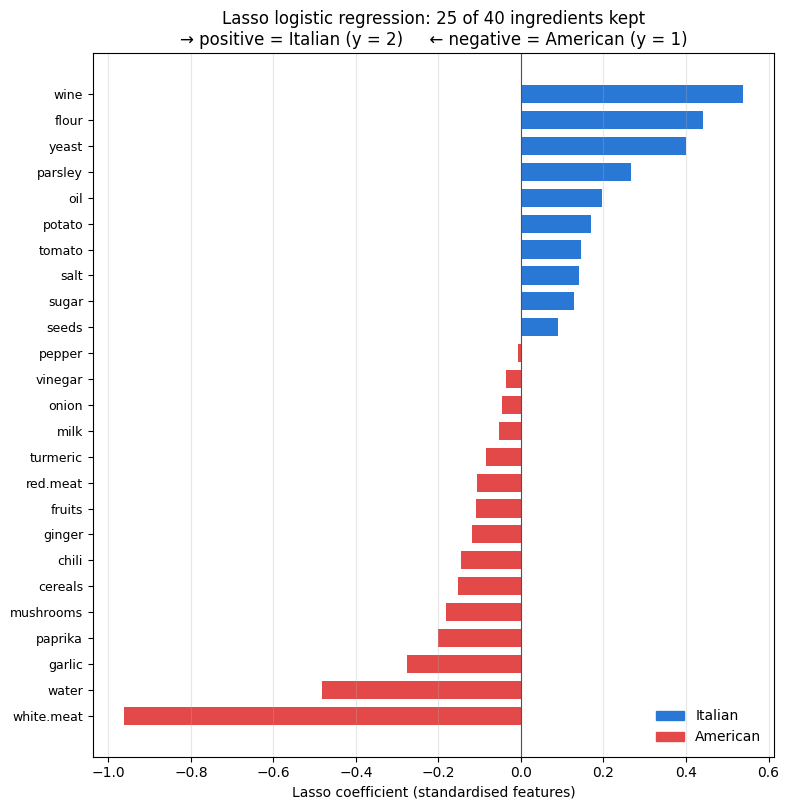

In [35]:
# (a) Lasso coefficients
lasso_coef = pd.Series(best_lasso_pipe.named_steps['clf'].coef_[0], index=X.columns)
assert list(best_lasso_pipe.named_steps['clf'].classes_) == [1, 2]   # positive = class 2 (Italian)
kept = lasso_coef[lasso_coef != 0].sort_values()
print(f'Non-zero coefficients: {len(kept)} of {len(lasso_coef)}')
print('\nItalian side (positive):')
print(kept[kept > 0].sort_values(ascending=False).round(3).to_string())
print('\nAmerican side (negative):')
print(kept[kept < 0].round(3).to_string())
print('\nSet to zero:', sorted(lasso_coef[lasso_coef == 0].index))

fig, ax = plt.subplots(figsize=(8, 0.28 * len(kept) + 1.2))
colors = [BLUE if c > 0 else RED for c in kept.values]
ax.barh(kept.index, kept.values, color=colors, height=0.7)
ax.axvline(0, color='#52514e', linewidth=0.8)
ax.set_xlabel('Lasso coefficient (standardised features)')
ax.set_title(f'Lasso logistic regression: {len(kept)} of 40 ingredients kept\n'
             '→ positive = Italian (y = 2)     ← negative = American (y = 1)')
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', labelsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label='Italian'), Patch(color=RED, label='American')],
          loc='lower right', frameon=False)
plt.tight_layout()
save_fig('lasso_coefficients.png')
plt.show()

            bagging  random_forest  bagging_rank  rf_rank
flour        0.0888         0.0811             1        1
oil          0.0709         0.0562             2        4
water        0.0643         0.0733             3        2
sugar        0.0564         0.0441             4        6
salt         0.0499         0.0591             5        3
white.meat   0.0453         0.0455             6        5
wine         0.0408         0.0362             7        8
garlic       0.0380         0.0355             8        9
egg          0.0355         0.0421             9        7
seeds        0.0332         0.0318            10       13
cheese       0.0317         0.0322            11       12
butter       0.0308         0.0317            12       14
fruits       0.0281         0.0340            13       10
pepper       0.0277         0.0328            14       11
bread        0.0254         0.0205            15       21

Spearman rank correlation (bagging vs RF, 40 ingredients): 0.980
Ingred

Saved figures/ingredient_importance.png


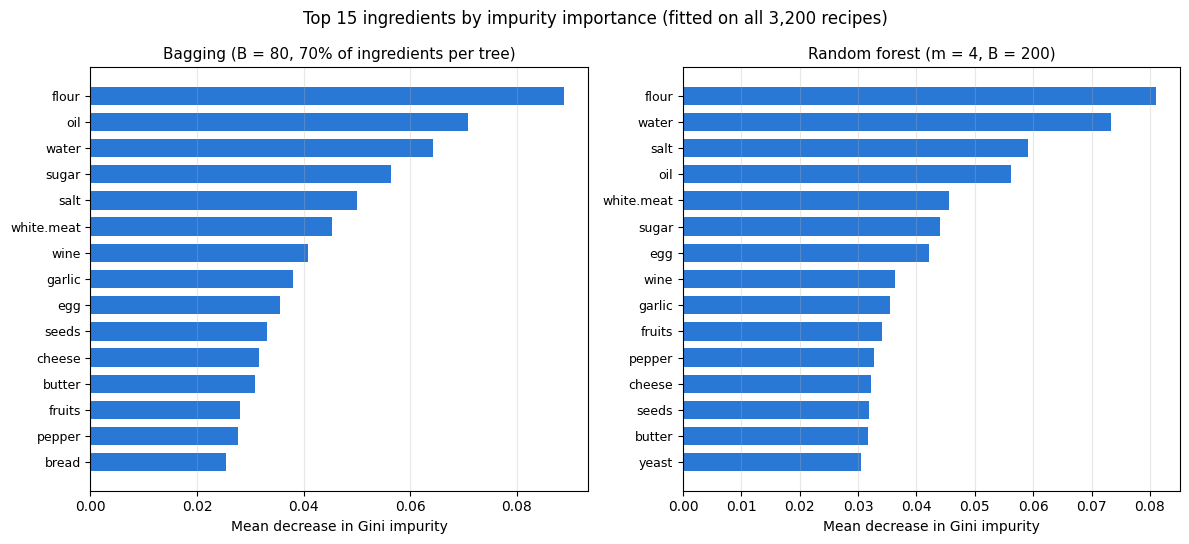

In [36]:
# (b) Tree-ensemble importances
rf_imp_model = RandomForestClassifier(n_estimators=200, max_features=4, random_state=SEED, n_jobs=-1)
rf_imp_model.fit(X, y)
rf_importances = pd.Series(rf_imp_model.feature_importances_, index=X.columns).sort_values(ascending=False)

imp = pd.DataFrame({'bagging': bag_importances, 'random_forest': rf_importances})
imp['bagging_rank'] = imp['bagging'].rank(ascending=False).astype(int)
imp['rf_rank'] = imp['random_forest'].rank(ascending=False).astype(int)
print(imp.sort_values('bagging', ascending=False).head(15).round(4).to_string())
print(f"\nSpearman rank correlation (bagging vs RF, 40 ingredients): "
      f"{imp['bagging'].corr(imp['random_forest'], method='spearman'):.3f}")
top10_both = set(bag_importances.head(10).index) & set(rf_importances.head(10).index)
print(f'Ingredients in the top 10 of both: {len(top10_both)} → {sorted(top10_both)}')

TOP = 15
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=False)
for ax, (title, s) in zip(axes, [('Bagging (B = 80, 70% of ingredients per tree)', bag_importances),
                                 ('Random forest (m = 4, B = 200)', rf_importances)]):
    top = s.head(TOP)[::-1]
    ax.barh(top.index, top.values, color=BLUE, height=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Mean decrease in Gini impurity')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=9)
fig.suptitle(f'Top {TOP} ingredients by impurity importance (fitted on all 3,200 recipes)', fontsize=12)
plt.tight_layout()
save_fig('ingredient_importance.png')
plt.show()

### Reading the two views together

All statements below refer to the outputs of the two cells above.

**Lasso (direction of association).** The tuned Lasso keeps 25 of the 40 ingredients.
- *Italian side (positive):* wine (0.538), flour (0.440), yeast (0.401) and parsley (0.268) have the largest coefficients, followed by oil, potato, tomato, salt, sugar and seeds.
- *American side (negative):* white meat has the largest coefficient of any ingredient in absolute value (−0.963), followed by water (−0.482), garlic (−0.276), paprika (−0.202), mushrooms (−0.182), cereals and chili.
- *Set to zero:* bread, butter, cheese, chocolate, corn, cream, egg, fish, honey, legumes, mustard, pasta, rice, seafood and veggies. A zero coefficient means the ingredient adds nothing to this regularised *linear* model given the others, not that it is uninformative.

**Tree ensembles (how much each ingredient is used).** The bagging and random-forest importance rankings agree closely (Spearman rank correlation 0.980), and nine ingredients are in the top 10 of both: flour, oil, water, sugar, salt, white meat, wine, garlic and egg. Flour ranks first in both.

**Where the views agree and differ.**
- Most of the top tree ingredients also have non-zero Lasso coefficients: flour, oil, wine, salt and sugar on the Italian side; water, white meat and garlic on the American side.
- Egg (rank 9 in bagging, 7 in the random forest), cheese (11 and 12) and butter (12 and 14) are used often by the trees but are set to zero by the Lasso. This is consistent with Section 6: these ingredients matter through non-linear effects or interactions that a linear model cannot use.
- Importances are impurity-based: they show how much an ingredient is used to split, not in which direction it pushes the prediction.

---
## 15. Results summary: CV accuracy by method

All entries come from the `results` dictionary: one 10-fold CV evaluation per chosen model, on the same folds. Searches that selected the hyperparameters used the same data, so these accuracies are slightly optimistic (see README, Limitations).

In [37]:
res_df = (pd.DataFrame(results).T
          .assign(cv_acc=lambda d: d['cv_acc'].astype(float), cv_std=lambda d: d['cv_std'].astype(float))
          .sort_values('cv_acc', ascending=False))
res_df['cv_misclass_%'] = 100 * (1 - res_df['cv_acc'])
print(res_df[['family', 'cv_acc', 'cv_std', 'cv_misclass_%']]
      .to_string(float_format=lambda v: f'{v:.4f}'))

print('\nBest model per family:')
best_per_family = res_df.groupby('family', sort=False).head(1)
print(best_per_family[['family', 'cv_acc']].to_string(float_format=lambda v: f'{v:.4f}'))

                                                                family  cv_acc  cv_std  cv_misclass_%
Stacking (RF+GBM+XGB+SVM C=10)                               Ensembles  0.9238  0.0095         7.6250
Stacking (RF+GBM+XGB+2 SVMs)                                 Ensembles  0.9225  0.0099         7.7500
Stacking (RF+GBM+XGB+AdaBoost+Lasso)                         Ensembles  0.9219  0.0122         7.8125
Stacking (RF+GBM+XGB+SVM unscaled)                           Ensembles  0.9216  0.0121         7.8437
Stacking (5 learners, meta C=50)                             Ensembles  0.9216  0.0095         7.8438
Final: 6-learner stack (LightGBM + passthrough)              Ensembles  0.9216  0.0092         7.8438
Stacking (RF+GBM+XGB)                                        Ensembles  0.9197  0.0122         8.0312
Random forest (m=sqrt(p), B=100)                                 Trees  0.9163  0.0139         8.3750
Random forest (m=4, B=200)                                       Trees  0.9156  0.

Saved figures/model_comparison_cv.png


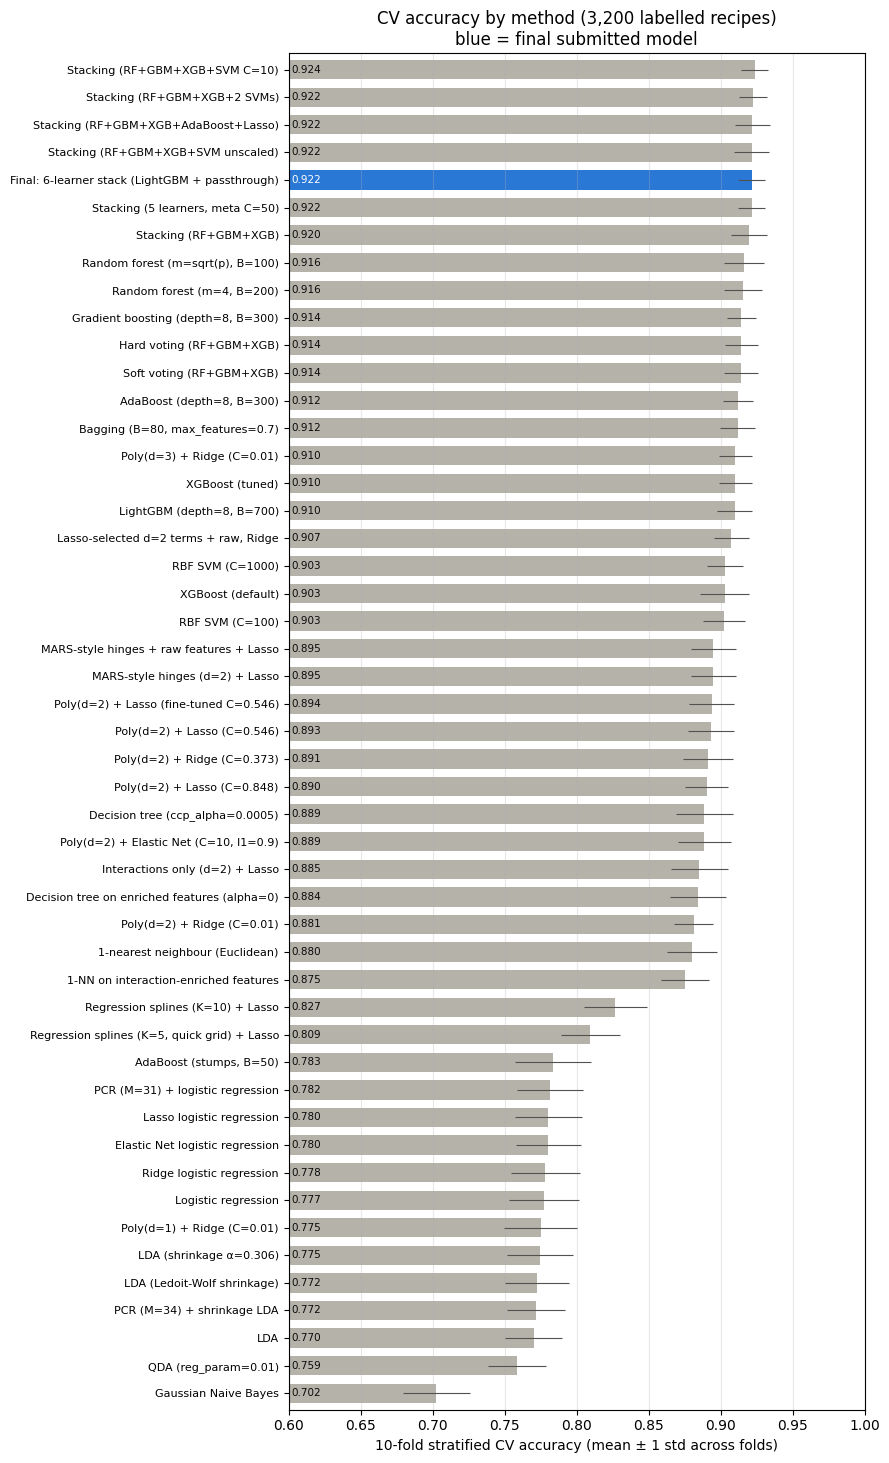

In [38]:
FINAL_NAME = 'Final: 6-learner stack (LightGBM + passthrough)'
plot_df = res_df.sort_values('cv_acc')
fig, ax = plt.subplots(figsize=(9, 0.27 * len(plot_df) + 1.5))
colors = [BLUE if n == FINAL_NAME else GREY for n in plot_df.index]
ax.barh(plot_df.index, plot_df['cv_acc'], xerr=plot_df['cv_std'], color=colors, height=0.7,
        error_kw={'elinewidth': 0.8, 'ecolor': '#52514e', 'capsize': 0})
for i, (n, v) in enumerate(plot_df['cv_acc'].items()):
    ax.text(0.602, i, f'{v:.3f}', va='center', fontsize=7.5,
            color='white' if n == FINAL_NAME else '#0b0b0b')
ax.set_xlim(0.6, 1.0)
ax.set_ylim(-0.6, len(plot_df) - 0.4)
ax.set_xlabel('10-fold stratified CV accuracy (mean ± 1 std across folds)')
ax.set_title('CV accuracy by method (3,200 labelled recipes)\nblue = final submitted model')
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
save_fig('model_comparison_cv.png')
plt.show()

---
## 16. Final submission file

Fits the final six-learner stack on all 3,200 training recipes and writes one predicted label per test recipe to `../submission.txt` (gitignored).

In [39]:
stacking_v2.fit(X, y)
preds = stacking_v2.predict(X_test)

assert len(preds) == len(X_test) == 1734
assert set(preds.astype(int)).issubset({1, 2})
np.savetxt(SUBMISSION_PATH, preds.astype(int), fmt='%d')
print(f'{SUBMISSION_PATH} saved: 1 (American): {(preds == 1).sum()}, 2 (Italian): {(preds == 2).sum()}')

..\submission.txt saved: 1 (American): 896, 2 (Italian): 838
